In [ ]:
!pip install backtesting

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.5/175.5 kB 1.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for backtesting: filename=Backtesting-0.3.3-py3-none-any.whl size=173916 sha256=c0b600b32c015b001516225ba289d5258526750a6d0257067d327de60f0bf7e9
  Stored in directory: /root/.cache/pip/wheels/e2/30/7f/19cbe31987c6ebdb47f1f510343249066711609e3da2d57176
Successfully built backtesting


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

In [ ]:
data=pd.read_csv("/content/drive/MyDrive/final_year_project/Final Data.csv")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1297301 entries, 0 to 1297300
Data columns (total 31 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Unnamed: 0                 1297301 non-null  int64  
 1   Date                       1297301 non-null  object 
 2   Open Price                 1297301 non-null  float64
 3   High Price                 1297301 non-null  float64
 4   Low Price                  1297301 non-null  float64
 5   Close Price                1297301 non-null  float64
 6   WAP                        1297301 non-null  float64
 7   No.of Shares               1297301 non-null  int64  
 8   No. of Trades              1297301 non-null  int64  
 9   Total Turnover (Rs.)       1297301 non-null  float64
 10  Deliverable Quantity       1293108 non-null  float64
 11  % Deli. Qty to Traded Qty  1293108 non-null  float64
 12  Spread High-Low            1297301 non-null  float64
 13  Spread Close

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/final_year_project/Features (1).csv')

In [ ]:
from backtesting import Backtest
from backtesting import Strategy

/usr/local/lib/python3.10/dist-packages/backtesting/_plotting.py:50: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support (e.g. PyCharm, Spyder IDE). Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


In [ ]:
s_data1= data[data['Issuer Name'] == "Kotak Mahindra Bank Ltd."]

In [ ]:
s_data1.rename(columns={'Close Price': 'Close','Open Price':'Open','High Price':'High','Low Price':'Low'}, inplace=True)

<ipython-input-32-181dfedc27c8>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s_data1.rename(columns={'Close Price': 'Close','Open Price':'Open','High Price':'High','Low Price':'Low'}, inplace=True)


In [ ]:
selected_columns = ['Date','Open','High','Low','Close']
s_data2=s_data1[selected_columns].copy()

In [ ]:
s_data2.set_index('Date', inplace=True)
s_data2.index.name = None
s_data2.index = pd.to_datetime(s_data2.index)

In [ ]:
s_data2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1241 entries, 2023-03-31 to 2018-04-02
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1241 non-null   float64
 1   High    1241 non-null   float64
 2   Low     1241 non-null   float64
 3   Close   1241 non-null   float64
dtypes: float64(4)
memory usage: 48.5 KB


In [ ]:
from backtesting import Strategy, Backtest
from backtesting.lib import crossover
from backtesting.test import SMA

class SmaCross(Strategy):
    n1 = 126
    n2 = 252

    def init(self):
        close = self.data.Close
        self.sma1 = self.I(SMA, close, self.n1)
        self.sma2 = self.I(SMA, close, self.n2)

    def next(self):
        if crossover(self.sma1, self.sma2):
            self.buy()
        elif crossover(self.sma2, self.sma1):
            self.sell()

bt = Backtest(s_data2, SmaCross,
              cash=10000, commission=.002,
              exclusive_orders=True)

output1 = bt.run()
print(output1)

Start                     2018-04-02 00:00:00
End                       2023-03-31 00:00:00
Duration                   1824 days 00:00:00
Exposure Time [%]                   78.001612
Equity Final [$]                    2081.5515
Equity Peak [$]                      12460.85
Return [%]                         -79.184485
Buy & Hold Return [%]               57.964279
Return (Ann.) [%]                  -27.290643
Volatility (Ann.) [%]               24.540079
Sharpe Ratio                              0.0
Sortino Ratio                             0.0
Calmar Ratio                              0.0
Max. Drawdown [%]                  -83.883511
Avg. Drawdown [%]                   -9.945976
Max. Drawdown Duration     1198 days 00:00:00
Avg. Drawdown Duration      128 days 00:00:00
# Trades                                    7
Win Rate [%]                        28.571429
Best Trade [%]                        3.43332
Worst Trade [%]                    -73.631708
Avg. Trade [%]                    

<ipython-input-36-5a0f6e291a19>:20: UserWarning: Data index is not sorted in ascending order. Sorting.
  bt = Backtest(s_data2, SmaCross,


In [ ]:
import pandas as pd
comm1=pd.read_csv('/content/community_1_centrality_metric_updates.csv')
comm2=pd.read_csv('/content/community_2_centrality_metric_updates.csv')
comm3=pd.read_csv('/content/community_3_centrality_metric_updates.csv')
comm4=pd.read_csv('/content/community_4_centrality_metric_updates.csv')
comm5=pd.read_csv('/content/community_5_centrality_metric_updates.csv')
comm6=pd.read_csv('/content/community_6_centrality_metric_updates.csv')
comm7=pd.read_csv('/content/community_7_centrality_metric_updates.csv')
df=pd.concat([comm1, comm2, comm3, comm4,comm5,comm6,comm7], ignore_index=True)
print(df)

                                           Node  Combined Score  Sharpe Ratio  \
0                          AIA Engineering Ltd.        0.294339      1.506137   
1                   Reliance Infrastructure Ltd        0.293575      1.229821   
2            Equitas Small Finance Bank Limited        0.293552      2.036672   
3                           Sheela Foam Limited        0.293534      0.489348   
4                                SKF India Ltd.        0.291422      2.515989   
...                                         ...             ...           ...   
1127                           Dabur India Ltd.        0.187908      1.886064   
1128                      Info Edge(India) Ltd.        0.169139      1.435895   
1129                  Elpro International Ltd.,        0.340000      0.022469   
1130                              PNB Gilts Ltd        0.340000      0.357300   
1131  Rashtriya Chemicals & Fertilizers Limited        0.340000      0.012185   

      Closeness Centrality 

In [ ]:
#comm1=pd.read_csv('/content/community_1_centrality_metric.csv')
# ma_profit=0
# ma_com=None
profit_df = pd.DataFrame(columns=['Node', 'Profit Factor'])
for company in df['Node']:
    s_data1= data[data['Issuer Name'] ==company]

    s_data1.rename(columns={'Close Price': 'Close','Open Price':'Open','High Price':'High','Low Price':'Low'}, inplace=True)

    selected_columns = ['Date','Open','High','Low','Close']
    s_data2=s_data1[selected_columns].copy()

    s_data2.set_index('Date', inplace=True)
    s_data2.index.name = None
    s_data2.index = pd.to_datetime(s_data2.index)

    s_data2.info()

    from backtesting import Strategy, Backtest
    from backtesting.lib import crossover
    from backtesting.test import SMA

    class SmaCross(Strategy):
        n1 = 21
        n2 = 63

        def init(self):
            close = self.data.Close
            self.sma1 = self.I(SMA, close, self.n1)
            self.sma2 = self.I(SMA, close, self.n2)

        def next(self):
            if crossover(self.sma1, self.sma2):
                self.buy()
            elif crossover(self.sma2, self.sma1):
                self.sell()

    bt = Backtest(s_data2, SmaCross,
                  cash=10000, commission=.002,
                  exclusive_orders=True)

    output1 = bt.run()
    profit_f = output1['Profit Factor']
    # if(ma_profit<profit_f):
    #   ma_profit=profit_f
    #   ma_com=company

    # Append 'company' and 'profit_f' to the profit_df DataFrame
    profit_df = profit_df._append({'Node': company, 'Profit Factor': profit_f}, ignore_index=True)


<ipython-input-16-0e75431b6b39>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s_data1.rename(columns={'Close Price': 'Close','Open Price':'Open','High Price':'High','Low Price':'Low'}, inplace=True)
<ipython-input-16-0e75431b6b39>:38: UserWarning: Data index is not sorted in ascending order. Sorting.
  bt = Backtest(s_data2, SmaCross,


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1241 entries, 2023-03-31 to 2018-04-02
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1241 non-null   float64
 1   High    1241 non-null   float64
 2   Low     1241 non-null   float64
 3   Close   1241 non-null   float64
dtypes: float64(4)
memory usage: 48.5 KB


<ipython-input-16-0e75431b6b39>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s_data1.rename(columns={'Close Price': 'Close','Open Price':'Open','High Price':'High','Low Price':'Low'}, inplace=True)
<ipython-input-16-0e75431b6b39>:38: UserWarning: Data index is not sorted in ascending order. Sorting.
  bt = Backtest(s_data2, SmaCross,


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1241 entries, 2023-03-31 to 2018-04-02
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1241 non-null   float64
 1   High    1241 non-null   float64
 2   Low     1241 non-null   float64
 3   Close   1241 non-null   float64
dtypes: float64(4)
memory usage: 48.5 KB


<ipython-input-16-0e75431b6b39>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s_data1.rename(columns={'Close Price': 'Close','Open Price':'Open','High Price':'High','Low Price':'Low'}, inplace=True)
<ipython-input-16-0e75431b6b39>:38: UserWarning: Data index is not sorted in ascending order. Sorting.
  bt = Backtest(s_data2, SmaCross,


...

<ipython-input-16-0e75431b6b39>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s_data1.rename(columns={'Close Price': 'Close','Open Price':'Open','High Price':'High','Low Price':'Low'}, inplace=True)
<ipython-input-16-0e75431b6b39>:38: UserWarning: Data index is not sorted in ascending order. Sorting.
  bt = Backtest(s_data2, SmaCross,


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1240 entries, 2023-03-31 to 2018-04-02
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1240 non-null   float64
 1   High    1240 non-null   float64
 2   Low     1240 non-null   float64
 3   Close   1240 non-null   float64
dtypes: float64(4)
memory usage: 48.4 KB


<ipython-input-16-0e75431b6b39>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s_data1.rename(columns={'Close Price': 'Close','Open Price':'Open','High Price':'High','Low Price':'Low'}, inplace=True)
<ipython-input-16-0e75431b6b39>:38: UserWarning: Data index is not sorted in ascending order. Sorting.
  bt = Backtest(s_data2, SmaCross,


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1241 entries, 2023-03-31 to 2018-04-02
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1241 non-null   float64
 1   High    1241 non-null   float64
 2   Low     1241 non-null   float64
 3   Close   1241 non-null   float64
dtypes: float64(4)
memory usage: 48.5 KB
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1241 entries, 2023-03-31 to 2018-04-02
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1241 non-null   float64
 1   High    1241 non-null   float64
 2   Low     1241 non-null   float64
 3   Close   1241 non-null   float64
dtypes: float64(4)
memory usage: 48.5 KB


<ipython-input-16-0e75431b6b39>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s_data1.rename(columns={'Close Price': 'Close','Open Price':'Open','High Price':'High','Low Price':'Low'}, inplace=True)
<ipython-input-16-0e75431b6b39>:38: UserWarning: Data index is not sorted in ascending order. Sorting.
  bt = Backtest(s_data2, SmaCross,


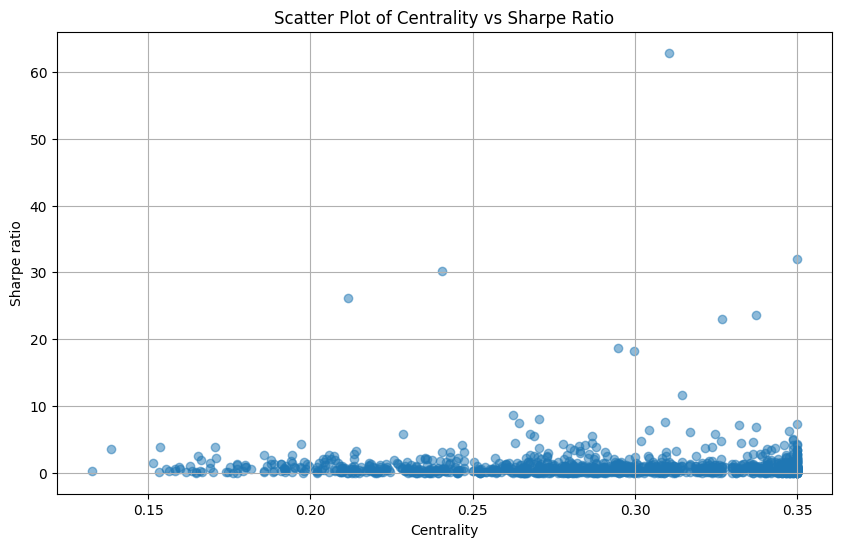

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming merged_df is your DataFrame with two columns you want to plot

# Plotting the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['Combined Score'], df['Sharpe Ratio'], alpha=0.5)
plt.title('Scatter Plot of Centrality vs Sharpe Ratio')
plt.xlabel('Centrality')
plt.ylabel('Sharpe ratio')
plt.grid(True)
plt.show()


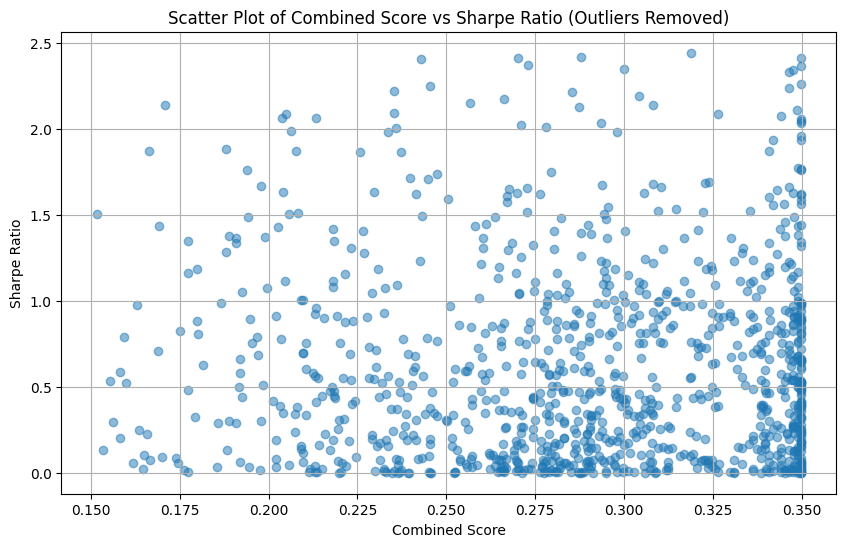

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame with 'Combined Score' and 'Sharpe Ratio' columns

# Define a function to remove outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Remove outliers from 'Combined Score' and 'Sharpe Ratio'
df = remove_outliers(df, 'Combined Score')
df = remove_outliers(df, 'Sharpe Ratio')

# Plotting the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['Combined Score'], df['Sharpe Ratio'], alpha=0.5)
plt.title('Scatter Plot of Combined Score vs Sharpe Ratio (Outliers Removed)')
plt.xlabel('Combined Score')
plt.ylabel('Sharpe Ratio')
plt.grid(True)
plt.show()


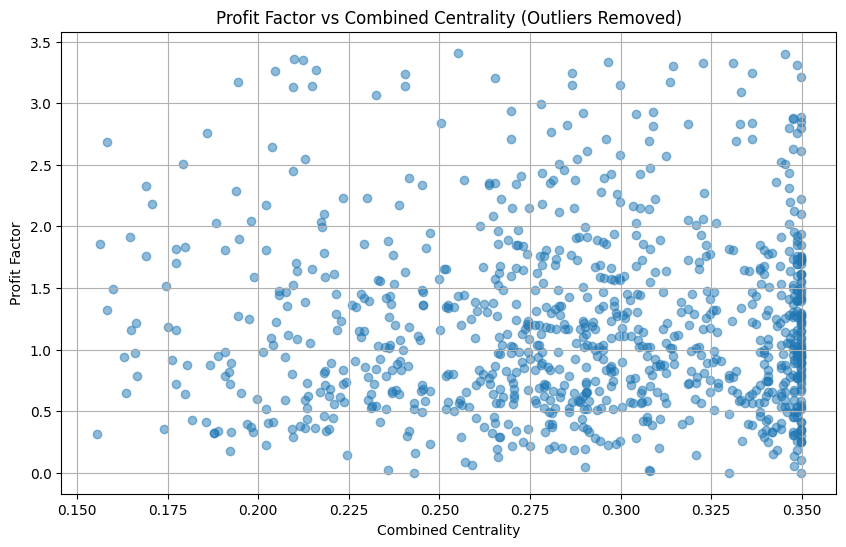

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Merge profit_df and comm1 DataFrames on the 'Node' column
merged_df = pd.merge(profit_df, df, on='Node')

# Define a function to remove outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Remove outliers from 'Combined Score' and 'Profit Factor'
merged_df = remove_outliers(merged_df, 'Combined Score')
merged_df = remove_outliers(merged_df, 'Profit Factor')

# Plotting the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(merged_df['Combined Score'], merged_df['Profit Factor'], alpha=0.5)
plt.title('Profit Factor vs Combined Centrality (Outliers Removed)')
plt.xlabel('Combined Centrality')
plt.ylabel('Profit Factor')
plt.grid(True)
plt.show()


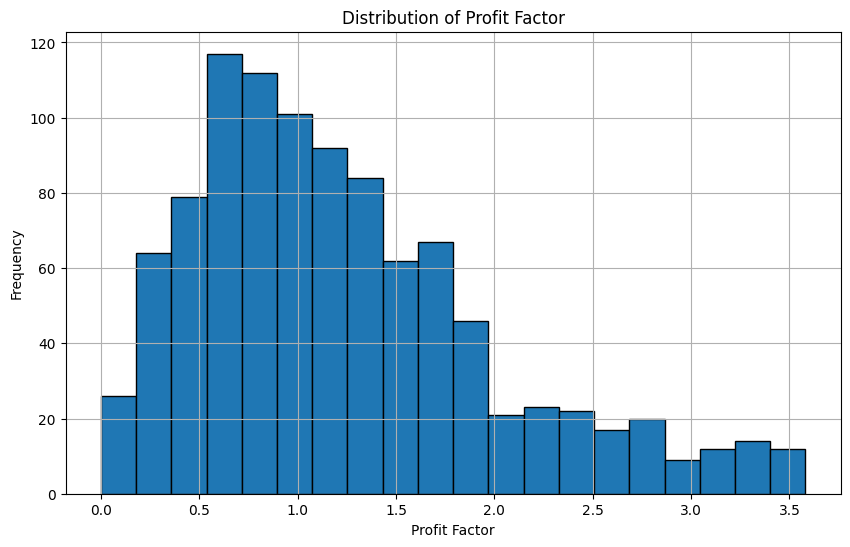

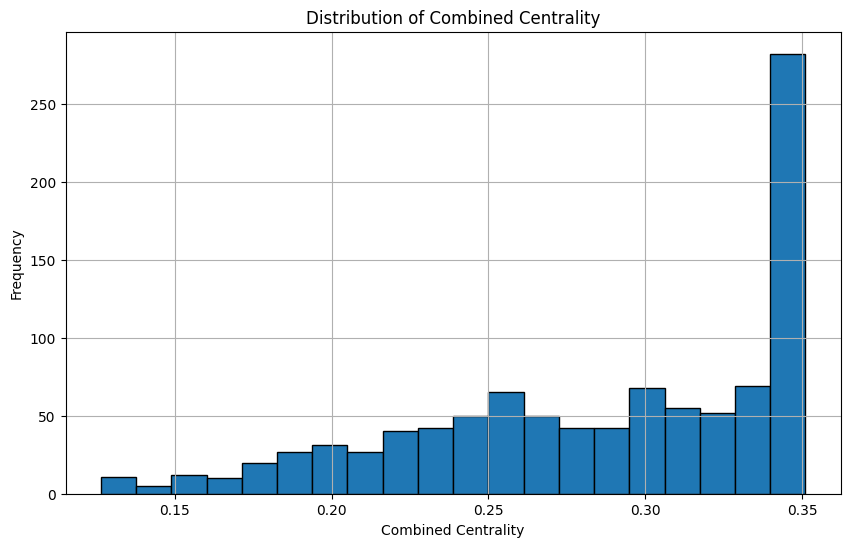

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Merge profit_df and comm1 DataFrames on the 'Node' column
merged_df = pd.merge(profit_df, df, on='Node')

# Define a function to remove outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Remove outliers from 'Profit Factor' and 'Combined Score'
merged_df = remove_outliers(merged_df, 'Profit Factor')
merged_df = remove_outliers(merged_df, 'Combined Score')

# Plotting the distribution of 'Profit Factor'
plt.figure(figsize=(10, 6))
plt.hist(merged_df['Profit Factor'], bins=20, edgecolor='black')
plt.title('Distribution of Profit Factor')
plt.xlabel('Profit Factor')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Plotting the distribution of 'Combined Centrality'
plt.figure(figsize=(10, 6))
plt.hist(merged_df['Combined Score'], bins=20, edgecolor='black')
plt.title('Distribution of Combined Centrality')
plt.xlabel('Combined Centrality')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


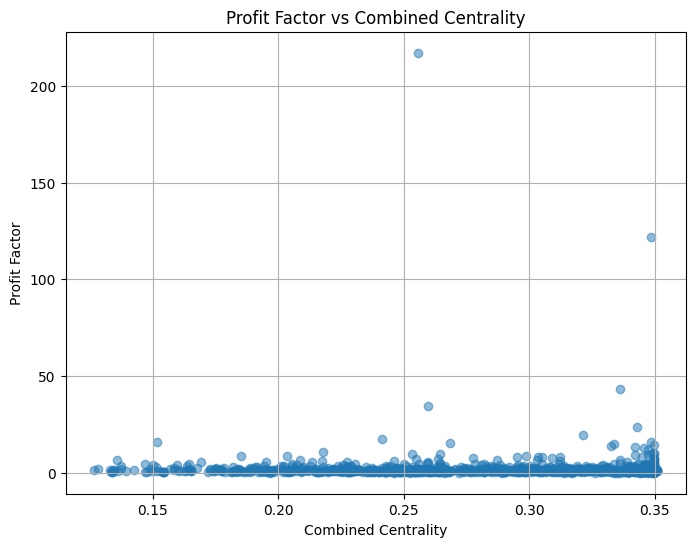

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Merge profit_df and comm1 DataFrames on the 'Node' column
merged_df = pd.merge(profit_df, df, on='Node')

# Plotting the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(merged_df['Combined Score'], merged_df['Profit Factor'], alpha=0.5)
plt.title('Profit Factor vs Combined Centrality')
plt.xlabel('Combined Centrality')
plt.ylabel('Profit Factor')
plt.grid(True)
plt.show()
